# Preliminary results

Previously trained model pipelines are used. New pipelines should be constructed later.

NOTE: currenlty, the unfiltered data contains data that are processed (reflection-corrected) and daytime filtered.

In [ ]:
import pandas as pd
import numpy as np
import sklearn.metrics
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from matplotlib.dates import DateFormatter, HourLocator
import datetime
import string


from helpers import config

In [4]:
SYSTEM_RATED_POWER_DICT = {"HEL" : config.rated_power_helsinki*1000,
                             "KUO" : config.rated_power_kuopio*1000,
                             "SOT-20" : config.rated_power_sodankyla*1000,
                             "SOT-90" : config.rated_power_sodankyla*1000,
                             "TKU" : config.rated_power_turku*1000}

SYSTEM_FILE_NAME_TO_ABBR = {"Helsinki" : "HEL",
                            "Kuopio" : "KUO",
                            "Sodankyla_20deg" : "SOT-20",
                            "Sodankyla_90deg" : "SOT-90", 
                            "KTK" : "TKU"}

SCENARIO_ABBR = {"scenario_1" : "S1",
                 "scenario_2" : "S2",
                 "scenario_3" : "S3",
                 "scenario_4" : "S4"}

In [ ]:
SCENARIO_HATCHES = {
    "scenario_1": "",
    "scenario_2": "",
    "scenario_3": "",
    "scenario_4": "///"

}

SCENARIO_GRAYS = ["#E0E0E0","#9E9E9E","#4D4D4D"]

viridis_colors = sns.color_palette(palette='viridis')
magma_colors = sns.color_palette(palette='magma')

MODEL_COLORS = {
"Huld_fit_plr_corr": ["#D9D2B6", "#AFA75E", "#4A4A18", "#4A4A18"],
"HGBR_fit_plr_corr": ["#A7D6D1", "#10BFAF", "#004F4A", "#004F4A"]
}

color_palette = ("#9ECAE1", "#4292C6", "#08519C",
                 "#FDBE85", "#FD8D3C", "#D94801")

SYSTEM_COLORS = {"HEL" : sns.color_palette("colorblind")[1],
                 "SOT-20" : sns.color_palette("colorblind")[2]}

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

In [7]:
from pathlib import Path

def find_project_root(start: Path = None) -> Path:
    """
    Walk upwards until we find a folder that contains 'data'.
    """
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "data").exists():
            return p
    raise FileNotFoundError("Could not find project root containing 'data'.")

ROOT = find_project_root()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"

ROOT, DATA_DIR, MODELS_DIR

(WindowsPath('c:/Users/viantt/git2/EUPVSEC-26'),
 WindowsPath('c:/Users/viantt/git2/EUPVSEC-26/data'),
 WindowsPath('c:/Users/viantt/git2/EUPVSEC-26/models'))

### Load data for each scenario

In [8]:
def pick_city_file(city_tag, folder, plr=None):
    folder_path = DATA_DIR / folder
    matches = sorted(folder_path.glob(f"*{city_tag}*.csv"))

    if not matches:
        raise FileNotFoundError(f"No CSV found for city tag '{city_tag}' in {folder_path}")

    if plr is not None:
        matches = [m for m in matches if f"PLR-{plr}" in str(m)]
        if len(matches) == 0:
            print(f"No CSV files with PLR-{plr} found")

    return matches[0]

In [10]:
def set_utctime_index(df, col="utctime"):
    """
    Ensure `col` exists, parse to datetime, set as index, sort.
    Works even if the index is already datetime.
    """
    df = df.copy()

    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)
        df = df.set_index(col)
    else:
        # If col isn't in columns, try converting the existing index
        df.index = pd.to_datetime(df.index, errors="coerce", utc=True)

    # Drop invalid timestamps and sort
    df = df[~df.index.isna()].sort_index()

    return df


In [ ]:
scenarios = ["scenario_1", "scenario_2", "scenario_3", "scenario_4"]
systems = ["Helsinki", "Kuopio", "Sodankyla_20deg", "Sodankyla_90deg", "KTK"]
scenario_systems_dfs = {}

for scenario in scenarios:
    for system in systems:
        system_scenario_csv = pick_city_file(system, folder=f"with_predictions/{scenario}")
        df_system_scenario = pd.read_csv(system_scenario_csv, sep=",")
        df_system_scenario = set_utctime_index(df_system_scenario)
        if scenario not in scenario_systems_dfs:
            scenario_systems_dfs[scenario] = {system : df_system_scenario}
        else:
            scenario_systems_dfs[scenario].update({system : df_system_scenario})

Scenario: scenario_1
System: Helsinki
Scenario: scenario_1
System: Kuopio
Scenario: scenario_1
System: Sodankyla_20deg
Scenario: scenario_1
System: Sodankyla_90deg
Scenario: scenario_1
System: KTK
Scenario: scenario_2
System: Helsinki
Scenario: scenario_2
System: Kuopio
Scenario: scenario_2
System: Sodankyla_20deg
Scenario: scenario_2
System: Sodankyla_90deg
Scenario: scenario_2
System: KTK
Scenario: scenario_3
System: Helsinki
Scenario: scenario_3
System: Kuopio
Scenario: scenario_3
System: Sodankyla_20deg
Scenario: scenario_3
System: Sodankyla_90deg
Scenario: scenario_3
System: KTK
Scenario: scenario_4
System: Helsinki
Scenario: scenario_4
System: Kuopio
Scenario: scenario_4
System: Sodankyla_20deg
Scenario: scenario_4
System: Sodankyla_90deg
Scenario: scenario_4
System: KTK


### Plot results

In [ ]:
def plot_actual_vs_modelled_power_all_scenarios(full_data_dict, model_str_list, save_figure_path="", dpi=300, show_decimals=3,
    show_dates=False, plot_days=[0, 9999], only_test_data=True):
    """
    Plot actual versus modelled power scatter plots for multiple PV systems,
    models, and scenarios.

    The function creates a grid of scatter plots comparing measured power
    against modelled power. Rows correspond to PV systems and columns
    correspond to model families. Different scenarios are visualized using
    distinct colors, and the coefficient of determination (R²) is displayed
    in the subplot legend for each scenario.

    Parameters
    ----------
    full_data_dict : dict
        Nested dictionary of the form::

            {
                scenario_name: {
                    system_name: dataframe,
                    ...
                },
                ...
            }

        Each DataFrame must be indexed by datetime and contain:
        - 'power' : measured PV power (W)
        - model prediction columns listed in `model_str_list`
        - 'training_flag' : boolean flag indicating training samples
        (required when `only_test_data=True`)

    model_str_list : list of str
        List of model column names to evaluate. Model columns are grouped
        according to their prefixes, with each prefix occupying one column
        in the output figure.

    save_figure_path : str, optional
        Path where the figure is saved. If empty, the figure is not saved.

    dpi : int, optional
        Figure resolution in dots per inch. Default is 300.

    show_decimals : int, optional
        Number of decimal places used when displaying R² values in the
        legend. Default is 3.

    show_dates : bool, optional
        If True, the starting date of the displayed period is included in
        the row labels.

    plot_days : list of int, optional
        Two-element list specifying the first and last day indices
        relative to the beginning of each dataset. Only data within this
        range are included in the analysis. Default is [0, 9999].

    only_test_data : bool, optional
        If True, only samples with `training_flag == False` are used.
        Default is True.

    Returns
    -------
    None
        Displays the generated figure and optionally saves it to disk.

    Notes
    -----
    - Rows correspond to PV systems and columns correspond to model
    families, where model families are determined from the prefixes of
    column names in `model_str_list`.
    - Different scenarios are represented using colors defined in
    `MODEL_COLORS`.
    - Scatter plots compare measured power (x-axis) to modelled power
    (y-axis).
    - Missing model predictions (NaN values) are excluded before
    calculating statistics and plotting.
    - The coefficient of determination (R²) is calculated using
    `sklearn.metrics.r2_score` and reported separately for each scenario.
    - A 1:1 reference line is drawn in each subplot to indicate perfect
    agreement between measured and modelled power.
    - Axes are scaled equally and use common limits within each system,
    enabling direct visual comparison among models.
    - Tick labels are removed to maximize plotting area and emphasize the
    agreement patterns.
    - Requires predefined mappings including `MODEL_COLORS`,
    `SCENARIO_ABBR`, and `SYSTEM_FILE_NAME_TO_ABBR`.
    - The input DataFrames are not modified.
    """

    dpi_scale = dpi/300
    
    plt.rcParams.update({
        "axes.linewidth": 0.8 * dpi_scale,
        "grid.linewidth": 0.5 * dpi_scale,
        "lines.linewidth": 1.2 * dpi_scale,
        "xtick.major.width": 0.8 * dpi_scale,
        "ytick.major.width": 0.8 * dpi_scale,
        "xtick.major.size": 3.5 * dpi_scale,
        "ytick.major.size": 3.5 * dpi_scale,
    })

    # ------------------------------------------------------------------
    # Build dictionary: {model_prefix: [suffix1, suffix2, ...]}
    # ------------------------------------------------------------------
    model_prefix_suffix_dict = {}

    for model_str in model_str_list:
        model_prefix, model_suffix = model_str.split("_")[0], "_".join(model_str.split("_")[1:])
        model_prefix_suffix_dict.setdefault(model_prefix, []).append(model_suffix)

    scenario_names = list(full_data_dict.keys())

    first_scenario = scenario_names[0]
    system_names = list(full_data_dict[first_scenario].keys())

    model_items = list(model_prefix_suffix_dict.items())

    # ------------------------------------------------------------------
    # Figure layout (transposed)
    # ------------------------------------------------------------------
    nrows = len(system_names)     # systems
    ncols = len(model_items)      # models

    target_width_px = 860 * dpi_scale
    fig_width = target_width_px / dpi  # inches
    fig_height = fig_width * (nrows / ncols)

    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(fig_width, fig_height),
        dpi=dpi,
        constrained_layout=True,
        squeeze=False,
    )

    # ------------------------------------------------------------------
    # Loop over systems (rows)
    # ------------------------------------------------------------------
    for j, system_name in enumerate(system_names):

        highest_value_for_system = 0

        # ------------------------------------------------------------------
        # Loop over models (columns)
        # ------------------------------------------------------------------
        for i, (model_name, model_suffix_list) in enumerate(model_items):

            # Column titles
            if j == 0:
                axs[j, i].set_title(
                    model_name,
                    fontsize=8*dpi_scale,
                    y=1.06
                )

            #r2_text_lines = []
            legend_handles = []

            for k, scenario_name in enumerate(scenario_names):

                if system_name not in full_data_dict[scenario_name]:
                    continue

                system_data = full_data_dict[scenario_name][system_name]

                if only_test_data:
                    print("------------------------")
                    print("Only using test data: ")
                    print(f"Dataset size before filtering: {len(system_data)}")
                    system_data = system_data.loc[system_data["training_flag"] == False, :]
                    print(f"Dataset size after filtering: {len(system_data)}")
                    print("------------------------")

                first_date = system_data.index.min().normalize()

                starting_date = first_date + pd.Timedelta(days=plot_days[0])
                ending_date = first_date + pd.Timedelta(days=plot_days[1] + 1)

                system_data = system_data.loc[
                    (system_data.index >= starting_date)
                    & (system_data.index < ending_date)
                ]

                actual_power = system_data["power"]

                if len(actual_power) == 0:
                    continue

                highest_value_for_system = max(
                    highest_value_for_system,
                    actual_power.max()
                )

                # Row label
                if show_dates:
                    row_label = (
                        f"{SYSTEM_FILE_NAME_TO_ABBR[system_name]}\n"
                        f"{starting_date.strftime('%Y-%m-%d')}"
                    )
                else:
                    row_label = SYSTEM_FILE_NAME_TO_ABBR[system_name]
        
                axs[j, 0].set_ylabel(row_label, fontsize=7*dpi_scale)

                for model_suffix in model_suffix_list:

                    model_column = f"{model_name}_{model_suffix}"

                    if model_column not in system_data.columns:
                        continue

                    modelled_power = system_data[model_column]

                    highest_value_for_system = max(
                        highest_value_for_system,
                        modelled_power.max(),
                    )

                    clean_mask = ~modelled_power.isna()

                    actual_power_clean = actual_power[clean_mask]
                    modelled_power_clean = modelled_power[clean_mask]

                    if len(actual_power_clean) == 0:
                        continue

                    r2_score = sklearn.metrics.r2_score(
                        actual_power_clean,
                        modelled_power_clean,
                    )

                    r2_score_str = f"{r2_score:.{show_decimals}f}"

                    axs[j, i].scatter(
                        actual_power_clean,
                        modelled_power_clean,
                        s=0.1*dpi_scale,
                        alpha=0.05,
                        color=MODEL_COLORS[model_column][k],
                    )

                    # Create a dot + label handle for legend
                    legend_handles.append(
                        mlines.Line2D(
                            [], [], 
                            color=MODEL_COLORS[model_column][k],
                            marker='o', 
                            linestyle='None', 
                            markersize=3*dpi_scale,
                            label=f"{SCENARIO_ABBR[scenario_name]}: {r2_score_str}"
                        )
                    )


            axs[j,i].legend(
                handles=legend_handles,
                loc='upper left',
                bbox_to_anchor=(-0.13, 1.16),
                fontsize=8*dpi_scale,
                frameon=False,
                handletextpad=0.01,
                labelspacing=0.01
            )

            # 1:1 line
            axs[j, i].axline(
                (0, 0),
                (1, 1),
                linewidth=0.8*dpi_scale,
                color="black",
            )

            axs[j, i].set_aspect("equal", adjustable="box")

            axs[j, i].set_xlim(0, highest_value_for_system)
            axs[j, i].set_ylim(0, highest_value_for_system)

            axs[j, i].set_xticks([])
            axs[j, i].set_yticks([])

            axs[j, i].spines["top"].set_visible(False)
            axs[j, i].spines["right"].set_visible(False)

    fig.supxlabel(
        "Actual power (W)",
        fontsize=8*dpi_scale,
    )

    fig.supylabel(
        "Modeled power (W)",
        fontsize=8*dpi_scale,
    )


    if save_figure_path != "":
        plt.savefig(
            save_figure_path,
            dpi=dpi,
            bbox_inches="tight",
        )


    plt.show()

------------------------
Only using test data: 
Dataset size before filtering: 1299302
Dataset size after filtering: 1080137
------------------------
------------------------
Only using test data: 
Dataset size before filtering: 1295961
Dataset size after filtering: 1077878
------------------------
------------------------
Only using test data: 
Dataset size before filtering: 1105753
Dataset size after filtering: 927760
------------------------
------------------------
Only using test data: 
Dataset size before filtering: 1299302
Dataset size after filtering: 1080137
------------------------
------------------------
Only using test data: 
Dataset size before filtering: 1295961
Dataset size after filtering: 1077878
------------------------
------------------------
Only using test data: 
Dataset size before filtering: 1105753
Dataset size after filtering: 927760
------------------------
------------------------
Only using test data: 
Dataset size before filtering: 986596
Dataset size aft

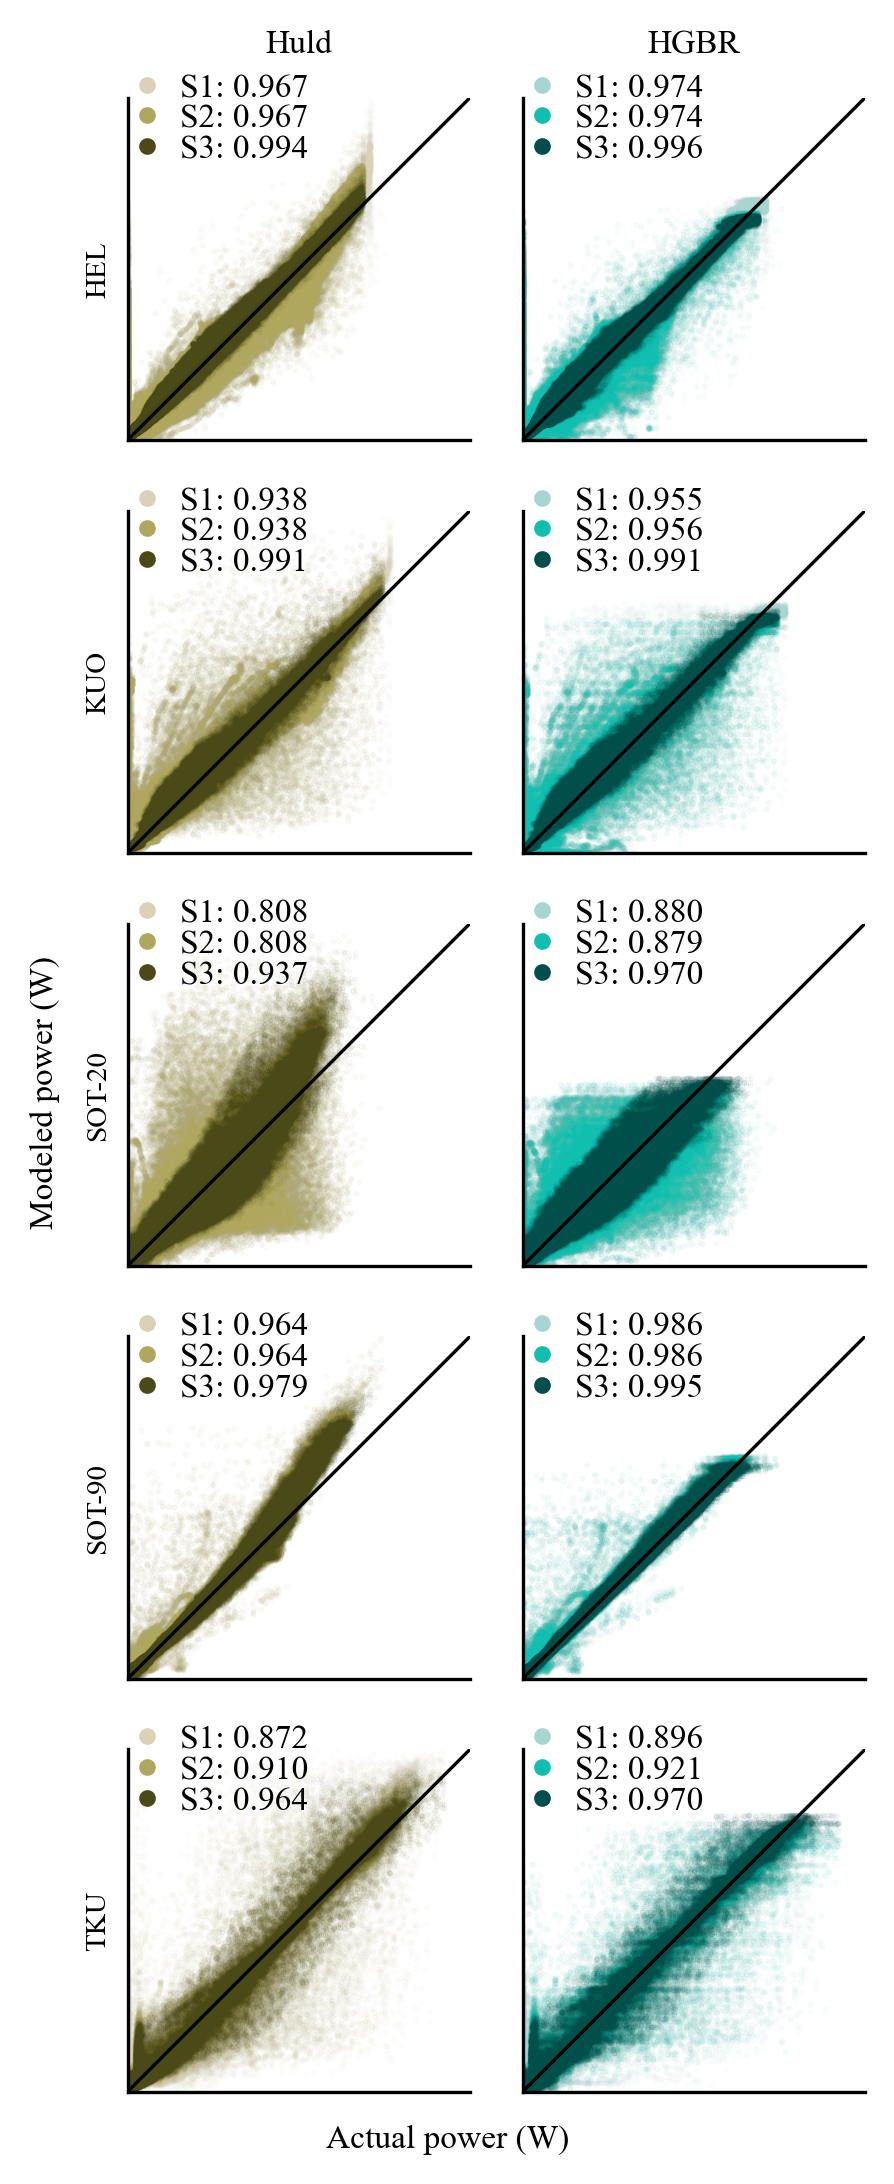

In [ ]:
plot_actual_vs_modelled_power_all_scenarios(
                            full_data_dict=dict(list(scenario_systems_dfs.items())[:-1]), 
                            #full_data_dict=scenario_systems_dfs,
                            model_str_list=["Huld_fit_plr_corr", "HGBR_fit_plr_corr"],
                            show_decimals=3,
                            dpi=300,
                            save_figure_path="results/R2_all_scenarios_all_systems_test_data.png"
                        )

------------------------
Only using test data: 
Dataset size before filtering: 1299302
Dataset size after filtering: 1080137
------------------------
------------------------
Only using test data: 
Dataset size before filtering: 1295961
Dataset size after filtering: 1077878
------------------------
------------------------
Only using test data: 
Dataset size before filtering: 1105753
Dataset size after filtering: 927760
------------------------
------------------------
Only using test data: 
Dataset size before filtering: 1105753
Dataset size after filtering: 927760
------------------------
------------------------
Only using test data: 
Dataset size before filtering: 1299302
Dataset size after filtering: 1080137
------------------------
------------------------
Only using test data: 
Dataset size before filtering: 1295961
Dataset size after filtering: 1077878
------------------------
------------------------
Only using test data: 
Dataset size before filtering: 1105753
Dataset size af

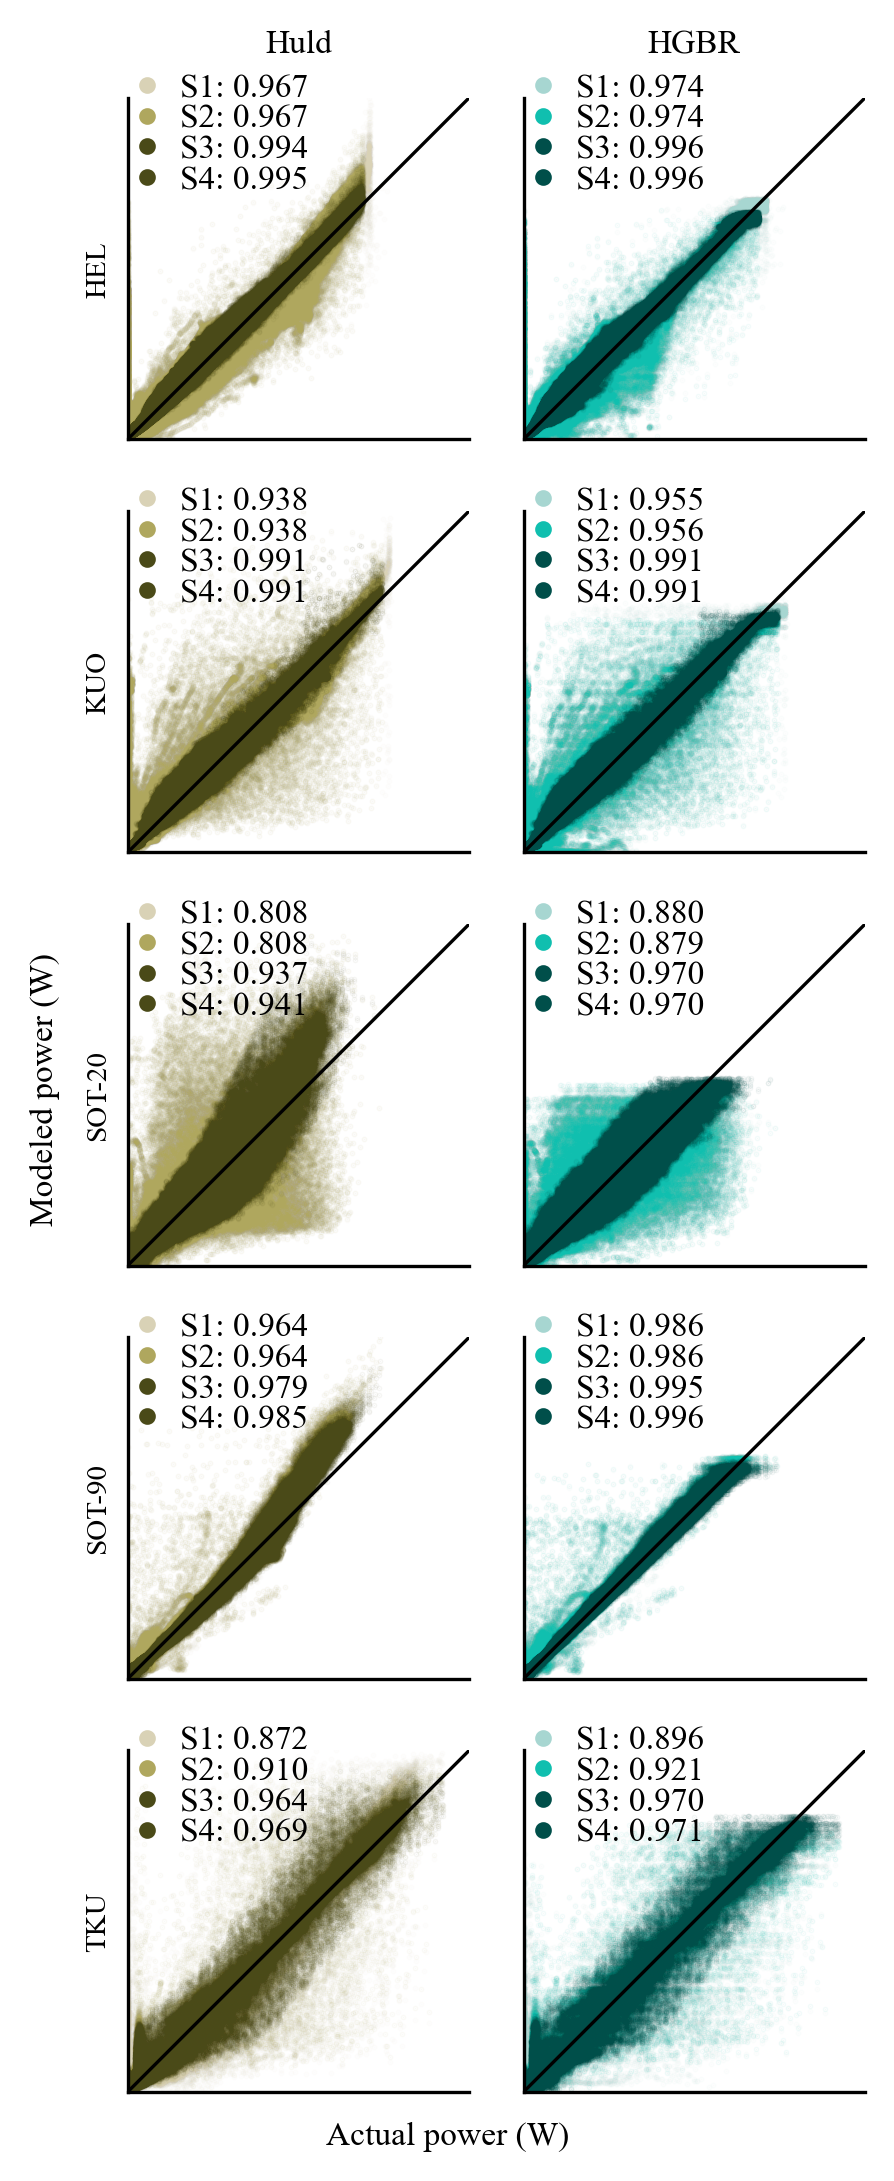

In [ ]:
plot_actual_vs_modelled_power_all_scenarios(
                            full_data_dict=scenario_systems_dfs, 
                            #full_data_dict=scenario_systems_dfs,
                            model_str_list=["Huld_fit_plr_corr", "HGBR_fit_plr_corr"],
                            show_decimals=3,
                            dpi=300,
                            #save_figure_path="results/R2_all_scenarios_all_systems.jpg"
                            only_test_data=True
                        )

In [ ]:
print(scenario_systems_dfs)

{'scenario_1': {'Helsinki':                                                 time   ghi   dhi    dni  \
utctime                                                                   
2015-12-21 11:58:00+00:00  2015-12-21 11:58:00+00:00   9.2   8.9    0.2   
2015-12-21 11:59:00+00:00  2015-12-21 11:59:00+00:00   9.5   9.4    0.1   
2015-12-21 12:00:00+00:00  2015-12-21 12:00:00+00:00   8.9   8.8    0.0   
2015-12-21 12:01:00+00:00  2015-12-21 12:01:00+00:00  10.4  10.2    0.1   
2015-12-21 12:02:00+00:00  2015-12-21 12:02:00+00:00  13.0  12.9    0.0   
...                                              ...   ...   ...    ...   
2021-12-20 10:55:00+00:00  2021-12-20 10:55:00+00:00  78.3  27.3  465.8   
2021-12-20 10:56:00+00:00  2021-12-20 10:56:00+00:00  79.8  27.5  464.4   
2021-12-20 10:57:00+00:00  2021-12-20 10:57:00+00:00  78.8  27.6  462.2   
2021-12-20 10:58:00+00:00  2021-12-20 10:58:00+00:00  77.3  27.4  458.8   
2021-12-20 10:59:00+00:00  2021-12-20 10:59:00+00:00  78.0  29.8  455.7 

In [ ]:
from collections import defaultdict

systems_scenarios_df = defaultdict(dict)

for scenario, systems in scenario_systems_dfs.items():
    for system, data in systems.items():
        systems_scenarios_df[system][scenario] = data

systems_scenarios_df = dict(systems_scenarios_df)

In [ ]:
print(systems_scenarios_df)

{'Helsinki': {'scenario_1':                                                 time   ghi   dhi    dni  \
utctime                                                                   
2015-12-21 11:58:00+00:00  2015-12-21 11:58:00+00:00   9.2   8.9    0.2   
2015-12-21 11:59:00+00:00  2015-12-21 11:59:00+00:00   9.5   9.4    0.1   
2015-12-21 12:00:00+00:00  2015-12-21 12:00:00+00:00   8.9   8.8    0.0   
2015-12-21 12:01:00+00:00  2015-12-21 12:01:00+00:00  10.4  10.2    0.1   
2015-12-21 12:02:00+00:00  2015-12-21 12:02:00+00:00  13.0  12.9    0.0   
...                                              ...   ...   ...    ...   
2021-12-20 10:55:00+00:00  2021-12-20 10:55:00+00:00  78.3  27.3  465.8   
2021-12-20 10:56:00+00:00  2021-12-20 10:56:00+00:00  79.8  27.5  464.4   
2021-12-20 10:57:00+00:00  2021-12-20 10:57:00+00:00  78.8  27.6  462.2   
2021-12-20 10:58:00+00:00  2021-12-20 10:58:00+00:00  77.3  27.4  458.8   
2021-12-20 10:59:00+00:00  2021-12-20 10:59:00+00:00  78.0  29.8  455.7 

In [ ]:
def plot_annual_energy_yield_errors_all_systems_poster(system_scenario_dict, model_str_list, rated_power_list, plot_years=[], ylims=[-0.2, 0.4], save_figure_path="", dpi=300, show_spines=True, show_legend=True):
    """
    Plot annual energy yield prediction errors for multiple PV systems and
    scenarios using a poster-style layout.

    The function aggregates measured and modelled power data to annual energy
    yields (Wh/Wp) and visualizes model performance as annual relative energy
    yield errors. Each PV system is shown in a separate subplot, while bars
    represent different combinations of prediction models and data scenarios.

    Parameters
    ----------
    system_scenario_dict : dict
        Nested dictionary of the form::

            {
                system_name: {
                    scenario_name: dataframe,
                    ...
                },
                ...
            }

        Each DataFrame must be indexed by datetime and contain:
        - 'power' : measured PV power (W)
        - model prediction columns listed in `model_str_list`

    model_str_list : list of str
        List of model column names to evaluate (e.g., 'huld_gen',
        'pvusa_fit').

    rated_power_list : list of float
        Rated system powers (Wp), in the same order as the systems in
        `system_scenario_dict`. Used to normalize annual energy yields
        to Wh/Wp.

    plot_years : list of int, optional
        Years to include in the plot. If empty, all available years
        present in the first scenario are used.

    ylims : list or tuple of float, optional
        Y-axis limits for the relative error plots. Default is
        [-0.2, 0.4].

    save_figure_path : str, optional
        Path where the figure is saved. If empty, the figure is not saved.

    dpi : int, optional
        Figure resolution in dots per inch. Default is 300.

    show_spines : bool, optional
        If False, removes the top and right plot spines.

    show_legend : bool, optional
        If True, displays the legend in the first subplot.

    Returns
    -------
    None
        Displays the generated figure and optionally saves it to disk.

    Notes
    -----
    - Annual energy yields are computed by summing power values for each year
    and converting to Wh/Wp using the system rated power.
    - The conversion factor assumes a fixed temporal resolution of
    10 minutes (sum / 6).
    - Relative error is calculated as::

        (predicted_yield - measured_yield) / measured_yield

    - Measured annual yields are calculated using timestamps where
    measured power is positive.
    - Model annual yields are calculated using timestamps where both
    measured and modelled power are positive.
    - Missing values and non-positive power values are excluded from
    annual aggregation.
    - Relative errors are shown as dimensionless quantities (-), not
    percentages.
    - Bars are grouped by model and scenario for each year.
    - Scenario-specific hatching is obtained from
    `SCENARIO_HATCHES`, while model-scenario color combinations are
    obtained from `MODEL_COLORS`.
    - Requires predefined mappings including `MODEL_COLORS`,
    `SCENARIO_HATCHES`, `SCENARIO_ABBR`, and
    `SYSTEM_FILE_NAME_TO_ABBR`.
    - The input DataFrames are not modified.
    """

    dpi_scale = dpi/300

    plt.rcParams.update({
        "axes.linewidth": 0.8 * dpi_scale,
        "grid.linewidth": 0.5 * dpi_scale,
        "lines.linewidth": 1.2 * dpi_scale,
        "xtick.major.width": 0.8 * dpi_scale,
        "ytick.major.width": 0.8 * dpi_scale,
        "xtick.major.size": 3.5 * dpi_scale,
        "ytick.major.size": 3.5 * dpi_scale,
    })

    scenario_names = list(next(iter(system_scenario_dict.values())).keys())

    n_scenarios = len(scenario_names)
    n_models = len(model_str_list)
    n_systems = len(list(system_scenario_dict.keys()))
    n_bars = n_scenarios * n_models

    width = 0.09
    offsets = np.linspace(
        -width * (n_bars - 1) / 2,
        width * (n_bars - 1) / 2,
        n_bars
    )

    # Single-column journal figure
    column_width_mm = 73.6 * dpi_scale
    fig_width = column_width_mm / 25.4# inches

    fig_height = fig_width * n_systems * 0.9

    fig, axs = plt.subplots(
        nrows=n_systems,
        ncols=1,
        figsize=(fig_width, fig_height),
        dpi=dpi
    )

    if n_systems == 1:
        axs = [axs]

    for i, (system_name, scenario_data) in enumerate(system_scenario_dict.items()):

        ax = axs[i]
        rated_power = rated_power_list[i]

        actual_annual_dict = {}
        model_annual_dict = {}

        for scenario_name, df in scenario_data.items():
            df = df.copy()
            df["Year"] = df.index.year
            actual_mask = df["power"] > 0
            actual_annual = df.loc[actual_mask].groupby("Year")["power"].sum() / 6 / rated_power
            
            actual_annual_dict[scenario_name] = actual_annual
            model_annual_dict[scenario_name] = {}
            
            for model_str in model_str_list:
                mask = (df["power"] > 0) & (df[model_str] > 0)
                annual_sum = df.loc[mask].groupby("Year")[model_str].sum() / 6 / rated_power
                model_annual_dict[scenario_name][model_str] = annual_sum

        if plot_years:
            years = plot_years
        else:
            years = sorted(actual_annual_dict[scenario_names[0]].index.tolist())

        x = np.arange(len(years))

        bar_idx = 0

        for model_str in model_str_list:
            for scenario_name in scenario_names:
                scenario_index = int(scenario_name.split("_")[1]) - 1
                actual = actual_annual_dict[scenario_name].reindex(years)
                preds = model_annual_dict[scenario_name][model_str].reindex(years)
                errors = (preds - actual) / actual

                color=MODEL_COLORS[model_str][scenario_index]
                hatch=SCENARIO_HATCHES[scenario_name]

                ax.bar(
                    x + offsets[bar_idx],
                    errors,
                    width=width,
                    label=f"{model_str.split("_")[0]} {SCENARIO_ABBR[scenario_name]}",
                    color=color,
                    hatch=hatch,
                    edgecolor="black",
                    linewidth=0.7 * dpi_scale,
                    alpha=1,
                )

                bar_idx += 1

        ax.axhline(0, color="black", linewidth=0.8 * dpi_scale)
        #ax.set_title(system_str)
        ax.set_title("")  # Remove default title
        ax.text(0.01, 
                1.05, 
                SYSTEM_FILE_NAME_TO_ABBR[system_name], 
                transform=ax.transAxes,
                ha='left', 
                va='top', 
                fontsize=8 * dpi_scale, 
                fontweight='bold'
        )
        ax.set_ylabel("Relative Error (-)", fontsize=8 * dpi_scale)
        
        ax.tick_params(axis="x", which="both", bottom=True, labelbottom=True)

        ax.set_xticks(x)
        ax.set_xticklabels(
            [str(y) for y in years],
            #rotation=0,
            #ha="right",
            fontsize=8 * dpi_scale,
        )

        ax.set_yticks([-0.05, 0.00, 0.05, 0.1])
        ax.set_yticklabels([-0.05, 0.00, 0.05, 0.1], 
                                fontsize=8 * dpi_scale)

        ax.set_ylim([ylims[0], ylims[1]])
        ax.xaxis.grid(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4)


        if (i == 0) & show_legend:
            ax.legend(loc="upper center",
                    #bbox_to_anchor=(0.5, 0.89),
                    ncol=len(model_str_list),
                    frameon=False,
                    fontsize=7 * dpi_scale,)

        if show_spines == False:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    fig.tight_layout()

    if save_figure_path:
        plt.savefig(save_figure_path, bbox_inches="tight", dpi=dpi)



In [ ]:

def plot_annual_energy_yield_errors_all_systems(system_scenario_dict, model_str_list, rated_power_list, plot_years=[], ylims=[-20., 40], save_figure_path="", 
                                                dpi=300, show_spines=True, legend_index=-1):
    """
    Plot annual energy yield prediction errors for multiple PV systems and scenarios.

    The function aggregates measured and modelled power data to annual energy
    yields (Wh/Wp) and visualizes model performance as relative annual energy
    yield errors (%) for one or more PV systems. Each system is displayed in a
    separate subplot, while bars represent different combinations of prediction
    models and data scenarios.

    Parameters
    ----------
    system_scenario_dict : dict
        Nested dictionary of the form::

            {
                system_name: {
                    scenario_name: dataframe,
                    ...
                },
                ...
            }

        Each DataFrame must be indexed by datetime and contain:
        - 'power' : measured PV power (W)
        - model prediction columns listed in `model_str_list`

    model_str_list : list of str
        List of model column names to evaluate (e.g., 'huld_gen',
        'pvusa_fit').

    rated_power_list : list of float
        Rated system powers (Wp), in the same order as the systems in
        `system_scenario_dict`. Used to normalize annual energy yields
        to Wh/Wp.

    plot_years : list of int, optional
        Years to include in the plot. If empty, all available years
        present in the first scenario are used.

    ylims : list or tuple of float, optional
        Y-axis limits for the relative error plots in percent.
        Default is [-20, 40].

    save_figure_path : str, optional
        Path where the figure is saved. If empty, the figure is not saved.

    dpi : int, optional
        Figure resolution in dots per inch. Default is 300.

    show_spines : bool, optional
        If False, removes the top and right plot spines.

    legend_index : int, optional
        Index of the subplot where the legend is displayed.
        Default is -1 (last subplot).

    Returns
    -------
    None
        Displays the generated figure and optionally saves it to disk.

    Notes
    -----
    - Annual energy yields are computed by summing power values for each year
    and converting to Wh/Wp using the system rated power.
    - The conversion factor assumes a fixed temporal resolution of
    10 minutes (sum / 6).
    - Relative error is calculated as::

        (predicted_yield - measured_yield) / measured_yield * 100

    - Measured annual yields are calculated using timestamps where
    measured power is positive.
    - Model annual yields are calculated using timestamps where both
    measured and modelled power are positive.
    - Missing values and non-positive power values are excluded from
    annual aggregation.
    - Bars are grouped by model and scenario for each year.
    - Requires predefined mappings such as `MODEL_COLORS`,
    `SCENARIO_HATCHES`, `SCENARIO_ABBR`, and
    `SYSTEM_FILE_NAME_TO_ABBR`.
    - The input DataFrames are not modified.
    """
    
    dpi_scale = dpi/300

    plt.rcParams.update({
        "axes.linewidth": 0.8 * dpi_scale,
        "grid.linewidth": 0.5 * dpi_scale,
        "lines.linewidth": 1.2 * dpi_scale,
        "xtick.major.width": 0.8 * dpi_scale,
        "ytick.major.width": 0.8 * dpi_scale,
        "xtick.major.size": 3.5 * dpi_scale,
        "ytick.major.size": 3.5 * dpi_scale,
    })

    scenario_names = list(next(iter(system_scenario_dict.values())).keys())

    n_scenarios = len(scenario_names)
    n_models = len(model_str_list)
    n_systems = len(list(system_scenario_dict.keys()))
    n_bars = n_scenarios * n_models

    width = 0.09
    offsets = np.linspace(
        -width * (n_bars - 1) / 2,
        width * (n_bars - 1) / 2,
        n_bars
    )

    # Single-column journal figure
    column_width_mm = 73.6 * dpi_scale
    fig_width = column_width_mm / 25.4# inches

    fig_height = fig_width * n_systems * 0.9

    fig, axs = plt.subplots(
        nrows=n_systems,
        ncols=1,
        figsize=(fig_width, fig_height),
        dpi=dpi
    )

    if n_systems == 1:
        axs = [axs]

    for i, (system_name, scenario_data) in enumerate(system_scenario_dict.items()):

        ax = axs[i]
        rated_power = rated_power_list[i]

        actual_annual_dict = {}
        model_annual_dict = {}

        for scenario_name, df in scenario_data.items():
            df = df.copy()
            df["Year"] = df.index.year
            actual_mask = df["power"] > 0
            actual_annual = df.loc[actual_mask].groupby("Year")["power"].sum() / 6 / rated_power
            
            actual_annual_dict[scenario_name] = actual_annual
            model_annual_dict[scenario_name] = {}
            
            for model_str in model_str_list:
                mask = (df["power"] > 0) & (df[model_str] > 0)
                annual_sum = df.loc[mask].groupby("Year")[model_str].sum() / 6 / rated_power
                model_annual_dict[scenario_name][model_str] = annual_sum

        if plot_years:
            years = plot_years
        else:
            years = sorted(actual_annual_dict[scenario_names[0]].index.tolist())

        x = np.arange(len(years))

        bar_idx = 0

        for model_str in model_str_list:
            for scenario_name in scenario_names:
                scenario_index = int(scenario_name.split("_")[1]) - 1
                actual = actual_annual_dict[scenario_name].reindex(years)
                preds = model_annual_dict[scenario_name][model_str].reindex(years)
                errors = (preds - actual) / actual * 100

                color=MODEL_COLORS[model_str][scenario_index]
                hatch=SCENARIO_HATCHES[scenario_name]

                ax.bar(
                    x + offsets[bar_idx],
                    errors,
                    width=width,
                    label=f"{model_str.split("_")[0]} {SCENARIO_ABBR[scenario_name]}",
                    color=color,
                    hatch=hatch,
                    edgecolor="black",
                    linewidth=0.7 * dpi_scale,
                    alpha=1,
                )

                bar_idx += 1

        ax.axhline(0, color="black", linewidth=0.8 * dpi_scale)
        ax.set_title(SYSTEM_FILE_NAME_TO_ABBR[system_name], fontsize=8*dpi_scale) 

        ax.set_ylabel("Relative Error (%)", fontsize=8 * dpi_scale)
        
        ax.tick_params(axis="x", which="both", bottom=True, labelbottom=True)

        ax.set_xticks(x)
        ax.set_xticklabels(
            [str(y) for y in years],
            #rotation=0,
            #ha="right",
            fontsize=8 * dpi_scale,
        )

        ax.set_yticks([-5.0, 0.00, 5.0, 10])
        ax.set_yticklabels([-5.0, 0.0, 5.0, 10], fontsize=8 * dpi_scale)

        ax.set_ylim([ylims[0], ylims[1]])
        ax.xaxis.grid(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4)


        if i == legend_index:
            ax.legend(loc="upper center",
                    ncol=len(model_str_list),
                    frameon=False,
                    fontsize=7 * dpi_scale,)

        if show_spines == False:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

        # Add alphabetical label (A, B, C, ...)
        label = string.ascii_uppercase[i]
        ax.text(
            -0.15,
            1.077,
            label, 
            transform=ax.transAxes,
            fontweight='bold', 
            fontsize=8,
            va='top', 
            ha='left', 
            color='black')

    fig.tight_layout()

    if save_figure_path:
        plt.savefig(save_figure_path, bbox_inches="tight", dpi=dpi)



In [ ]:
scenario_systems_dfs["scenario_1"].keys()

dict_keys(['Helsinki', 'Kuopio', 'Sodankyla_20deg', 'Sodankyla_90deg', 'KTK'])

In [ ]:
scenario_data_hel = {"scenario_1" : scenario_systems_dfs["scenario_1"]["Helsinki"],
                     "scenario_2" : scenario_systems_dfs["scenario_2"]["Helsinki"],
                     "scenario_3" : scenario_systems_dfs["scenario_3"]["Helsinki"],
                     "scenario_4" : scenario_systems_dfs["scenario_4"]["Helsinki"]}

scenario_data_kuo = {"scenario_1" : scenario_systems_dfs["scenario_1"]["Kuopio"],
                     "scenario_2" : scenario_systems_dfs["scenario_2"]["Kuopio"],
                     "scenario_3" : scenario_systems_dfs["scenario_3"]["Kuopio"],
                     "scenario_4" : scenario_systems_dfs["scenario_4"]["Kuopio"]}


scenario_data_sod20 = {"scenario_1" : scenario_systems_dfs["scenario_1"]["Sodankyla_20deg"],
                     "scenario_2" : scenario_systems_dfs["scenario_2"]["Sodankyla_20deg"],
                     "scenario_3" : scenario_systems_dfs["scenario_3"]["Sodankyla_20deg"],
                     "scenario_4" : scenario_systems_dfs["scenario_4"]["Sodankyla_20deg"]}

scenario_data_sod90 = {"scenario_1" : scenario_systems_dfs["scenario_1"]["Sodankyla_90deg"],
                     "scenario_2" : scenario_systems_dfs["scenario_2"]["Sodankyla_90deg"],
                     "scenario_3" : scenario_systems_dfs["scenario_3"]["Sodankyla_90deg"],
                     "scenario_4" : scenario_systems_dfs["scenario_4"]["Sodankyla_90deg"]}

scenario_data_tku = {"scenario_1" : scenario_systems_dfs["scenario_1"]["KTK"],
                     "scenario_2" : scenario_systems_dfs["scenario_2"]["KTK"],
                     "scenario_3" : scenario_systems_dfs["scenario_3"]["KTK"],
                     "scenario_4" : scenario_systems_dfs["scenario_4"]["KTK"]}


model_str_list = ["Huld_fit_plr_corr", "HGBR_fit_plr_corr"]

plot_years_hel = [2018, 2019, 2020, 2021]

plot_years_kuo = plot_years_hel

plot_years_sot20 = [2018, 2019, 2020, 2021]

plot_years_sot90 = plot_years_sot20

plot_years_tku = plot_years_sot20

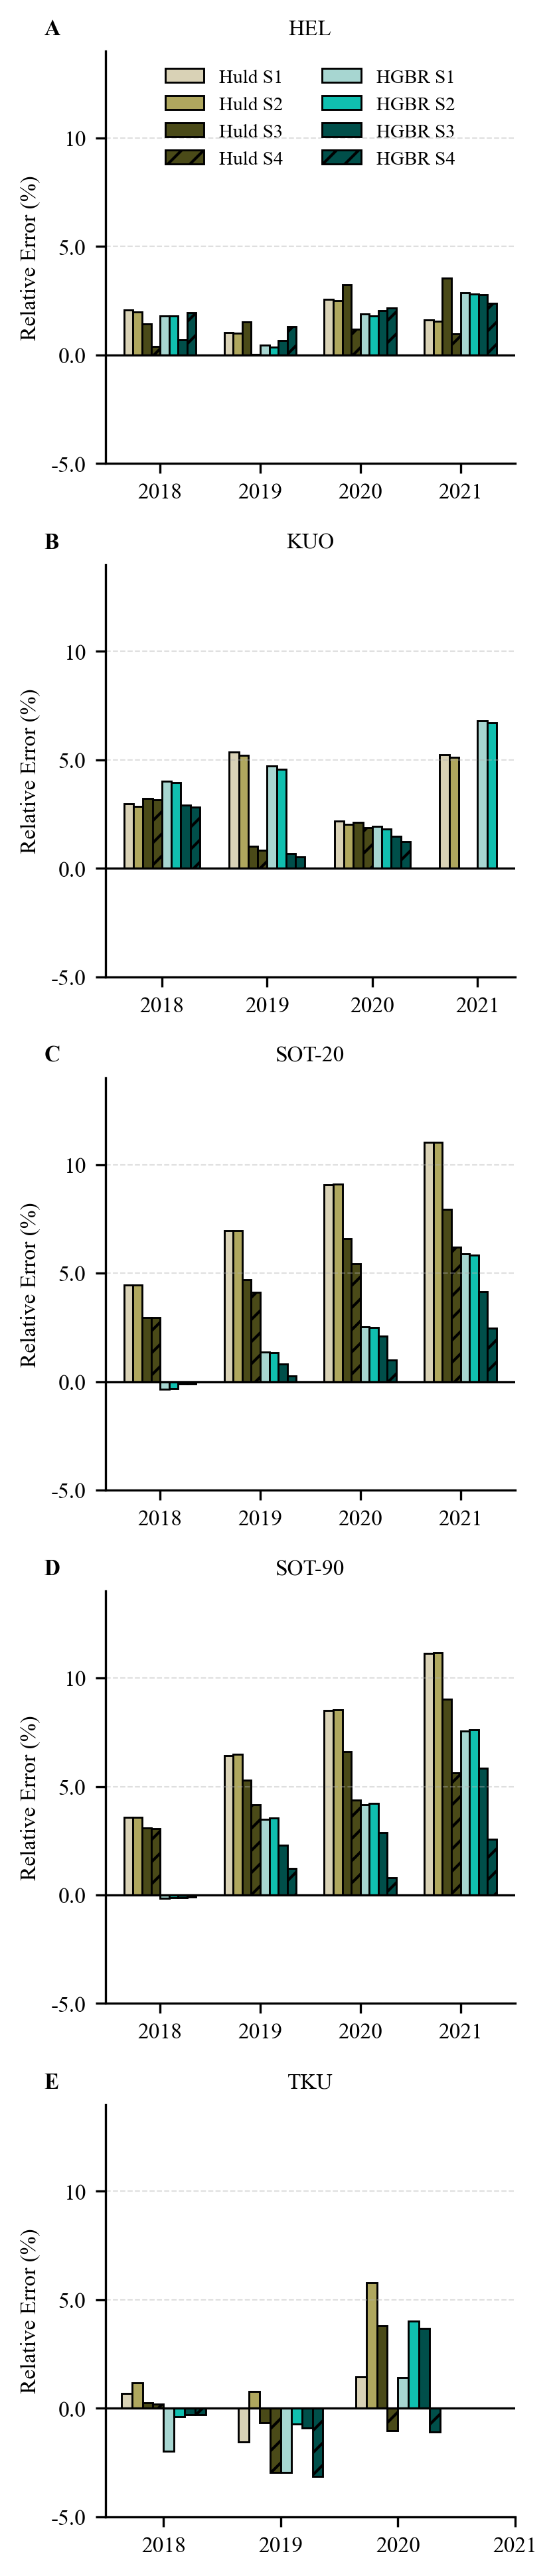

In [ ]:
plot_annual_energy_yield_errors_all_systems(system_scenario_dict=systems_scenarios_df, 
                                            model_str_list=model_str_list, 
                                            ylims=[-5, 14], 
                                            plot_years=plot_years_hel,
                                            rated_power_list=[SYSTEM_RATED_POWER_DICT["HEL"], SYSTEM_RATED_POWER_DICT["KUO"], SYSTEM_RATED_POWER_DICT["SOT-20"], SYSTEM_RATED_POWER_DICT["SOT-90"], SYSTEM_RATED_POWER_DICT["TKU"]], 
                                            show_spines=False,
                                            legend_index=0,
                                            save_figure_path=f"results/all_systems_annual_error_years-{"-".join([str(year) for year in plot_years_hel])}.jpg"
                                            )

In [ ]:
systems_scenarios_df_hel_kuo_sot20 = {"Helsinki" : systems_scenarios_df["Helsinki"], 
                                      "Kuopio" : systems_scenarios_df["Kuopio"],
                                      "Sodankyla_20deg" : systems_scenarios_df["Sodankyla_20deg"]}
systems_scenarios_df_sot90_tku = {"Sodankyla_90deg" : systems_scenarios_df["Sodankyla_90deg"], 
                                  "KTK" : systems_scenarios_df["KTK"]}

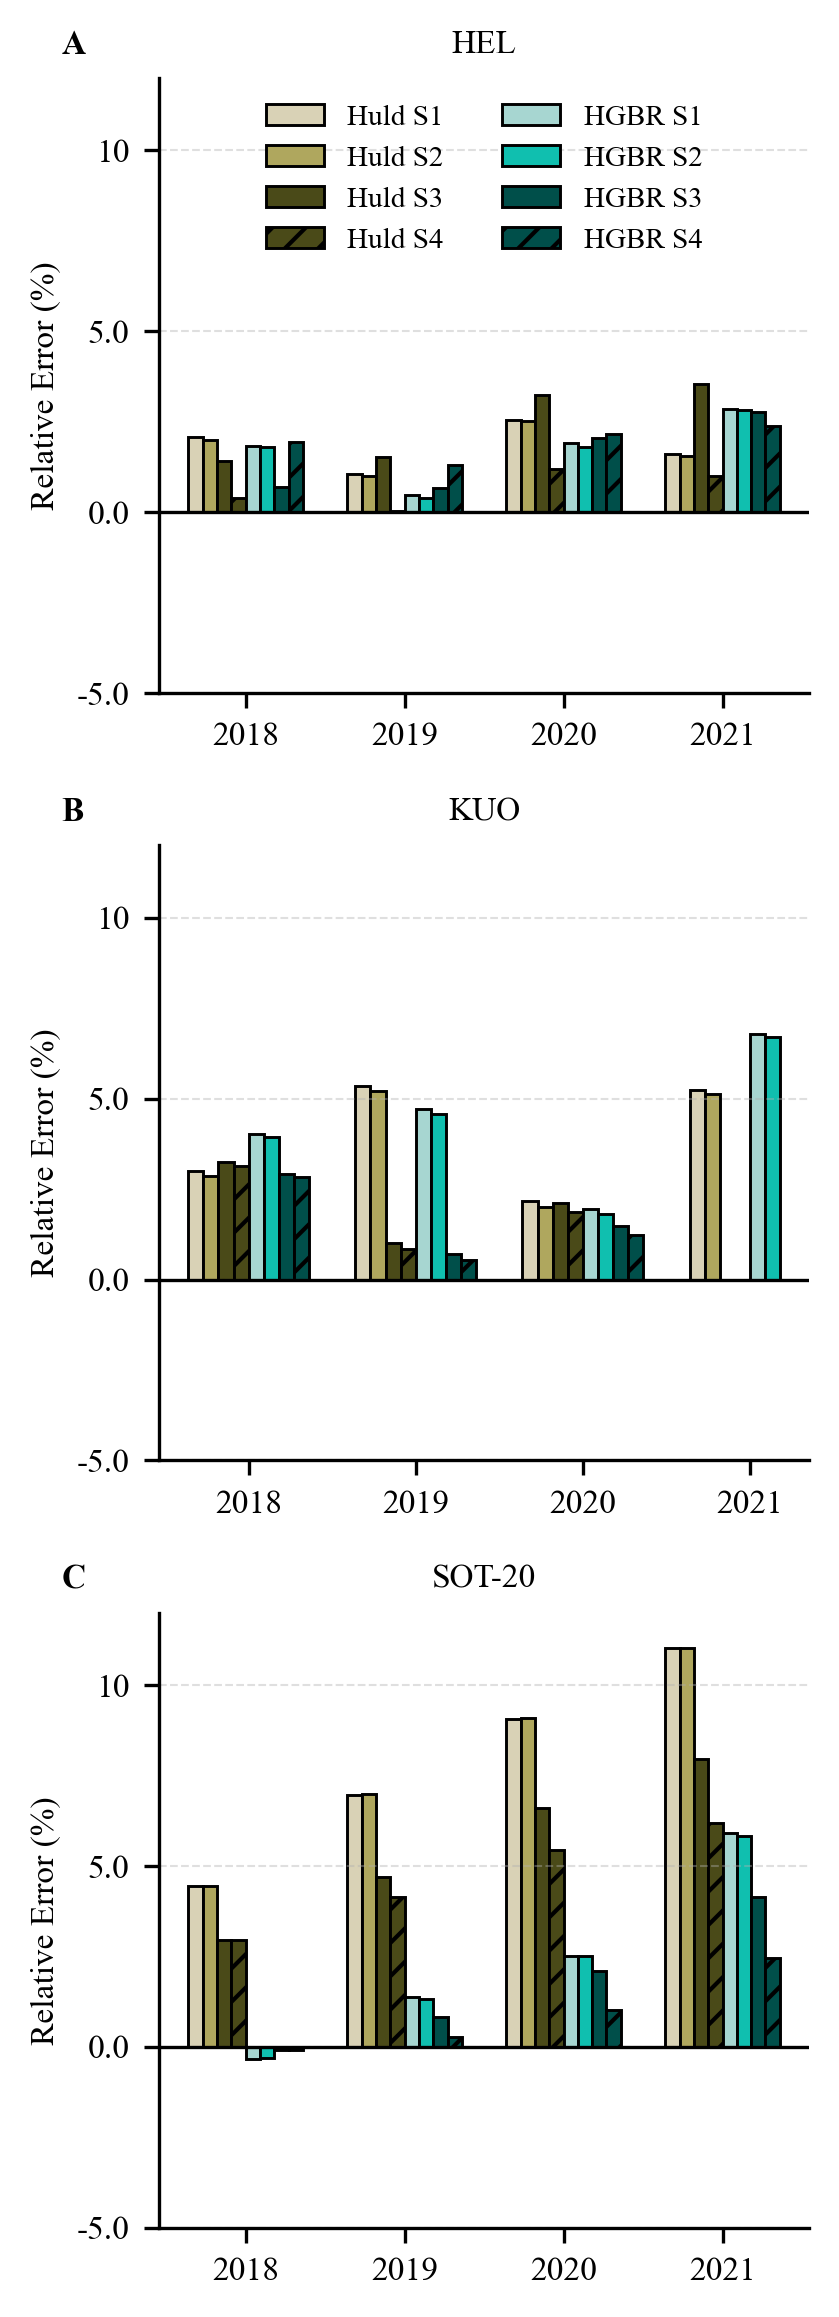

In [ ]:
plot_annual_energy_yield_errors_all_systems(system_scenario_dict=systems_scenarios_df_hel_kuo_sot20, 
                                            model_str_list=model_str_list, 
                                            ylims=[-5, 12], 
                                            plot_years=plot_years_hel,
                                            rated_power_list=[SYSTEM_RATED_POWER_DICT["HEL"], SYSTEM_RATED_POWER_DICT["KUO"], SYSTEM_RATED_POWER_DICT["SOT-20"]], 
                                            show_spines=False,
                                            legend_index=0,
                                            save_figure_path=f"results/hel_kuo_sot20_annual_error_years-{"-".join([str(year) for year in plot_years_hel])}.jpg"
                                            )

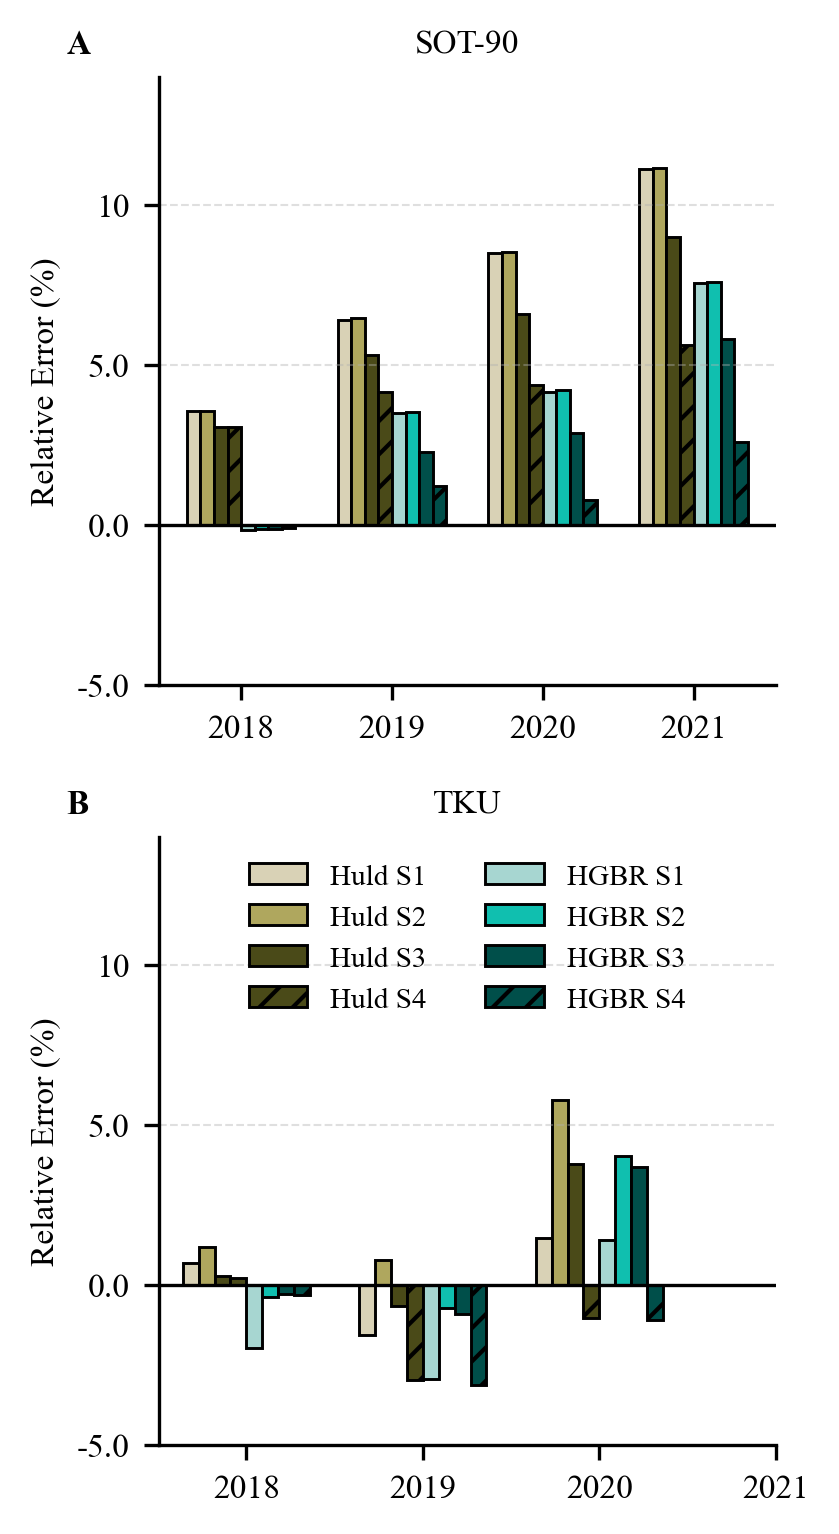

In [ ]:

plot_annual_energy_yield_errors_all_systems(system_scenario_dict=systems_scenarios_df_sot90_tku, 
                                            model_str_list=model_str_list, 
                                            ylims=[-5, 14], 
                                            plot_years=plot_years_hel,
                                            rated_power_list=[SYSTEM_RATED_POWER_DICT["SOT-90"], SYSTEM_RATED_POWER_DICT["TKU"]], 
                                            show_spines=False,
                                            legend_index=1,
                                            save_figure_path=f"results/sot90_tku_annual_error_years-{"-".join([str(year) for year in plot_years_hel])}.jpg"
                                            )

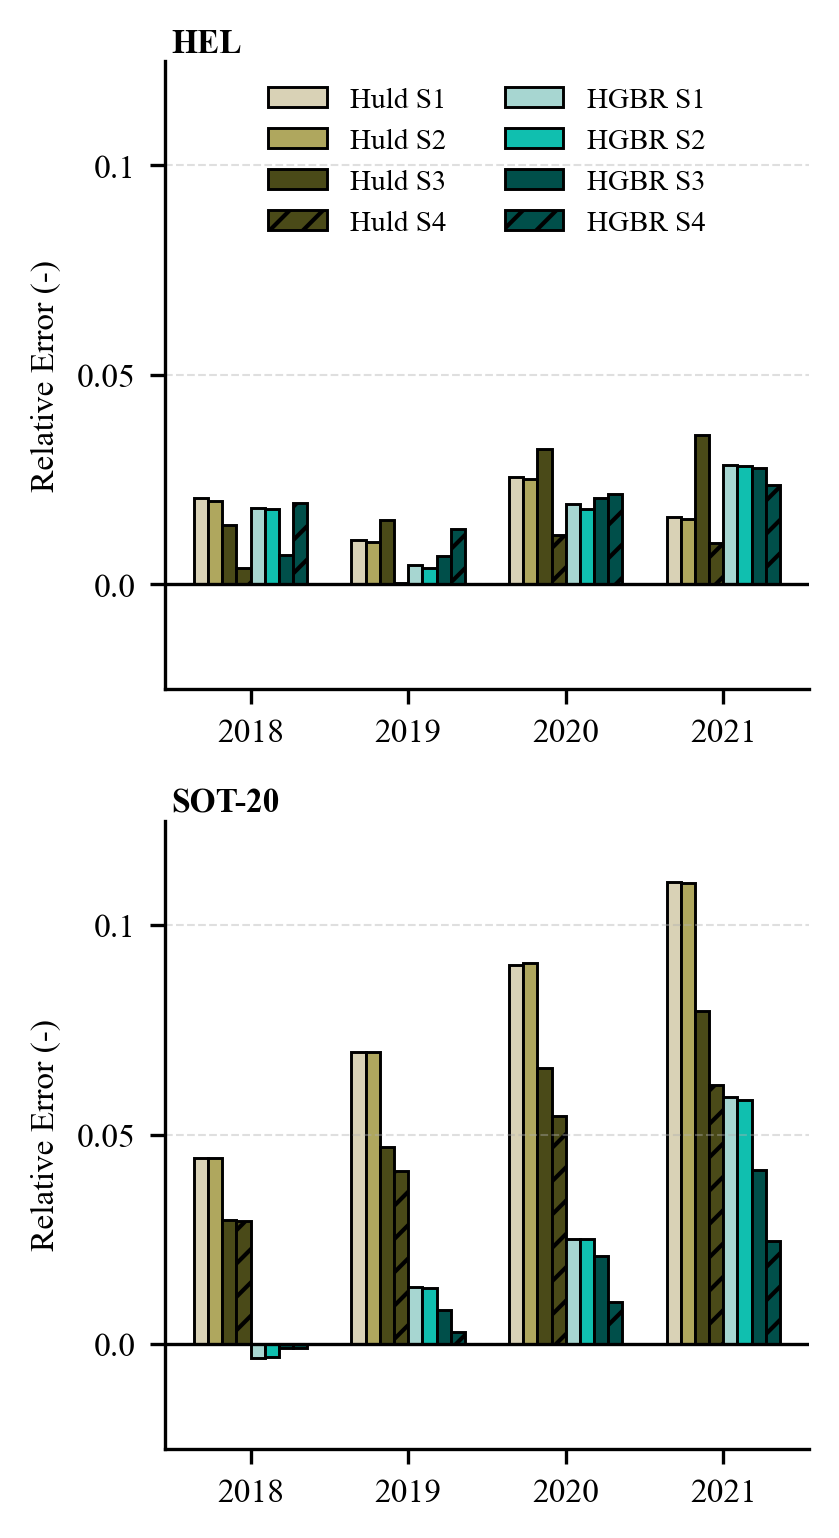

In [ ]:
plot_annual_energy_yield_errors_all_systems_poster(system_scenario_dict={"Helsinki" : scenario_data_hel, "Sodankyla_20deg" : scenario_data_sod20}, 
                                            model_str_list=model_str_list, 
                                            plot_years=plot_years_sot20, 
                                            rated_power_list=[SYSTEM_RATED_POWER_DICT["HEL"], SYSTEM_RATED_POWER_DICT["SOT-20"]], 
                                            show_spines=False,
                                            show_legend=True,
                                            ylims=[-0.025, 0.125],
                                            #save_figure_path=f"results/HEL-SOT-20_annual_error_years-{"-".join([str(year) for year in plot_years_sot20])}.png",
                                            dpi=300
                                            )

In [ ]:
SCENARIO_LINESTYLES = {
    "scenario_1": "-",
    "scenario_2": "--",
    "scenario_3": "-.",
    "scenario_4": ":"
}


def plot_power_profiles(system_scenario_dict, models, rated_power_list, start_date="", day_range=-1, save_figure_path="", dpi=300, starting_utc_time="", ending_utc_time=""):
    """
    Plot measured and modelled normalized power profiles for multiple PV
    systems and scenarios.

    The function visualizes measured power and model predictions as
    normalized power (W/Wp) time series. Each PV system is displayed in a
    separate subplot, while different scenario-model combinations are
    distinguished using colors and line styles.

    Parameters
    ----------
    system_scenario_dict : dict
        Nested dictionary of the form::

            {
                system_name: {
                    scenario_name: dataframe,
                    ...
                },
                ...
            }

        Each DataFrame must be indexed by datetime and contain:
        - 'power' : measured PV power (W)
        - model prediction columns listed in `models`

    models : list of str
        List of model column names to plot.

    rated_power_list : list of float
        Rated powers (Wp) of the systems, provided in the same order as
        the systems in `system_scenario_dict`. Used to normalize power
        values to W/Wp.

    start_date : str or pandas.Timestamp, optional
        Start date of the plotting period. If empty, the first timestamp
        of the reference scenario is used.

    day_range : int, optional
        Number of days to include starting from `start_date`.
        If -1, all available data are plotted.

    save_figure_path : str, optional
        Path where the figure is saved. If empty, the figure is not saved.

    dpi : int, optional
        Figure resolution in dots per inch. Default is 300.

    starting_utc_time : str, optional
        Daily start time (HH:MM) used to filter the plotted data.
        Applied together with `ending_utc_time`.

    ending_utc_time : str, optional
        Daily end time (HH:MM) used to filter the plotted data.
        Applied together with `starting_utc_time`.

    Returns
    -------
    None
        Displays the generated figure and optionally saves it to disk.

    Notes
    -----
    - Power values are normalized by the rated system power (Wp),
      resulting in units of W/Wp.
    - Measured power is taken from the first scenario associated with
      each system and plotted once as the reference series.
    - Model predictions are plotted separately for each scenario and
      model combination.
    - Data gaps larger than 2 minutes are visualized by inserting NaN
      values into the plotted model series, preventing lines from being
      drawn across missing periods.
    - A UTC+2 offset is applied to the displayed timestamps.
    - Scenario differentiation is handled using
      `SCENARIO_LINESTYLES`, while model-scenario color combinations
      are obtained from `MODEL_COLORS`.
    - Requires predefined mappings including `MODEL_COLORS`,
      `SCENARIO_LINESTYLES`, `SCENARIO_ABBR`, and
      `SYSTEM_FILE_NAME_TO_ABBR`.
    - The input DataFrames are not modified.
    """
    
    scenario_names = list(next(iter(system_scenario_dict.values())).keys())
    n_systems = len(list(system_scenario_dict.keys()))

    # Single-column journal figure
    column_width_mm = 73.6
    fig_width = column_width_mm / 25.4  # inches

    fig_height = fig_width * n_systems * 0.9

    fig, axs = plt.subplots(
        nrows=n_systems,
        ncols=1,
        figsize=(fig_width, fig_height),
        dpi=dpi)

    for i, (system_name, scenario_data) in enumerate(system_scenario_dict.items()):

        ax = axs[i]
        rated_power = rated_power_list[i]

        # Use first scenario for date limits and actual power
        reference_data = scenario_data[scenario_names[0]]

        if start_date == "":
            start_date = reference_data.index[0]
        else:
            start_date = pd.to_datetime(start_date, utc=True)

        if day_range == -1:
            end_date = reference_data.index[-1]
        else:
            end_date = start_date + datetime.timedelta(days=day_range)


        # ------------------------------------------------------------------
        # Actual power from first scenario
        # ------------------------------------------------------------------

        reference_data = reference_data.loc[
            (reference_data.index >= start_date)
            & (reference_data.index < end_date)
        ]

        if starting_utc_time and ending_utc_time:
            reference_data = reference_data.between_time(starting_utc_time, ending_utc_time)


        # ------------------------------------------------------------------
        # Model predictions
        # ------------------------------------------------------------------
        for model in models:

            for scenario_name in scenario_names:

                scenario_index = int(scenario_name.split("_")[1]) - 1
                data = scenario_data[scenario_name]

                data = data.loc[
                    (data.index >= start_date)
                    & (data.index < end_date)
                ]


                if starting_utc_time and ending_utc_time:
                    data = data.between_time(starting_utc_time, ending_utc_time)

                #Find gaps
                gap_mask = data.index.to_series().diff() > pd.Timedelta(minutes=2)

                # Copy so original dataframe is untouched
                plot_data = data.copy()

                # Insert NaNs at the start of each gap
                plot_data.loc[gap_mask, model] = np.nan

                linestyle = SCENARIO_LINESTYLES[scenario_name]

                ax.plot(
                    plot_data.index + datetime.timedelta(hours=2),
                    plot_data[model] / rated_power,
                    color=MODEL_COLORS[model][scenario_index],
                    label=f"{model.split("_")[0]} {SCENARIO_ABBR[scenario_name]}",
                    linestyle=linestyle,
                    linewidth=1,
                    #marker=".",
                    #s=2,
                    alpha=0.6,
                    #edgecolors='none'
                )

                mask = data["power"] > 0

                errors = pd.Series(
                    np.nan,
                    index=data.index
                )

                errors.loc[mask] = (
                    (data.loc[mask, model] - data.loc[mask, "power"])
                    / data.loc[mask, "power"]
                )

        ax.plot(
                reference_data.index + datetime.timedelta(hours=2),
                reference_data["power"] / rated_power,
                color="black",
                linewidth=1,
                label="Actual",
        )

        # Add 3 empty dummy plots for the legend 
        for _ in range(3):
            ax.plot(
                [], [], color="w", alpha=0, label=" ",
            )


        # ------------------------------------------------------------------
        # Formatting
        # ------------------------------------------------------------------

        ax.set_ylabel("Power (W/Wp)", fontsize=8)

        ax.set_xlabel(
            f"Time (UTC+2), {start_date.strftime('%d/%m/%Y')}", fontsize=8
        )

        ax.set_title(SYSTEM_FILE_NAME_TO_ABBR[system_name],
                     fontsize=8,
                     y=1.03)

        ax.tick_params(axis="x", which="major", labelsize=8)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
        ax.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2], fontsize=8)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if i == 0:
            ax.legend(loc="upper left",
                    ncol=3,
                    bbox_to_anchor=(0, 1.1),
                    frameon=False,
                    fontsize=7,)

        ax.set_ylim([0, 1.2])

        ax.tick_params(axis="x", which="both", bottom=True)
        ax.xaxis.set_major_locator(HourLocator(interval=1))
        ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))
        ax.grid(linestyle="--", alpha=0.4)


        # Add alphabetical label (A, B, C, ...)
        label = string.ascii_uppercase[i]
        ax.text(
            -0.15,
            1.12,
            label, 
            transform=ax.transAxes,
            fontweight='bold', 
            fontsize=8,
            va='top', 
            ha='left', 
            color='black')


    fig.tight_layout()

    if save_figure_path:
        plt.savefig(
            save_figure_path,
            bbox_inches="tight",
            dpi=dpi,
        )

In [ ]:
systems_scenarios_df_hel_sot20 = {"Helsinki" : systems_scenarios_df["Helsinki"],
                                "Sodankyla_20deg" : systems_scenarios_df["Sodankyla_20deg"]}

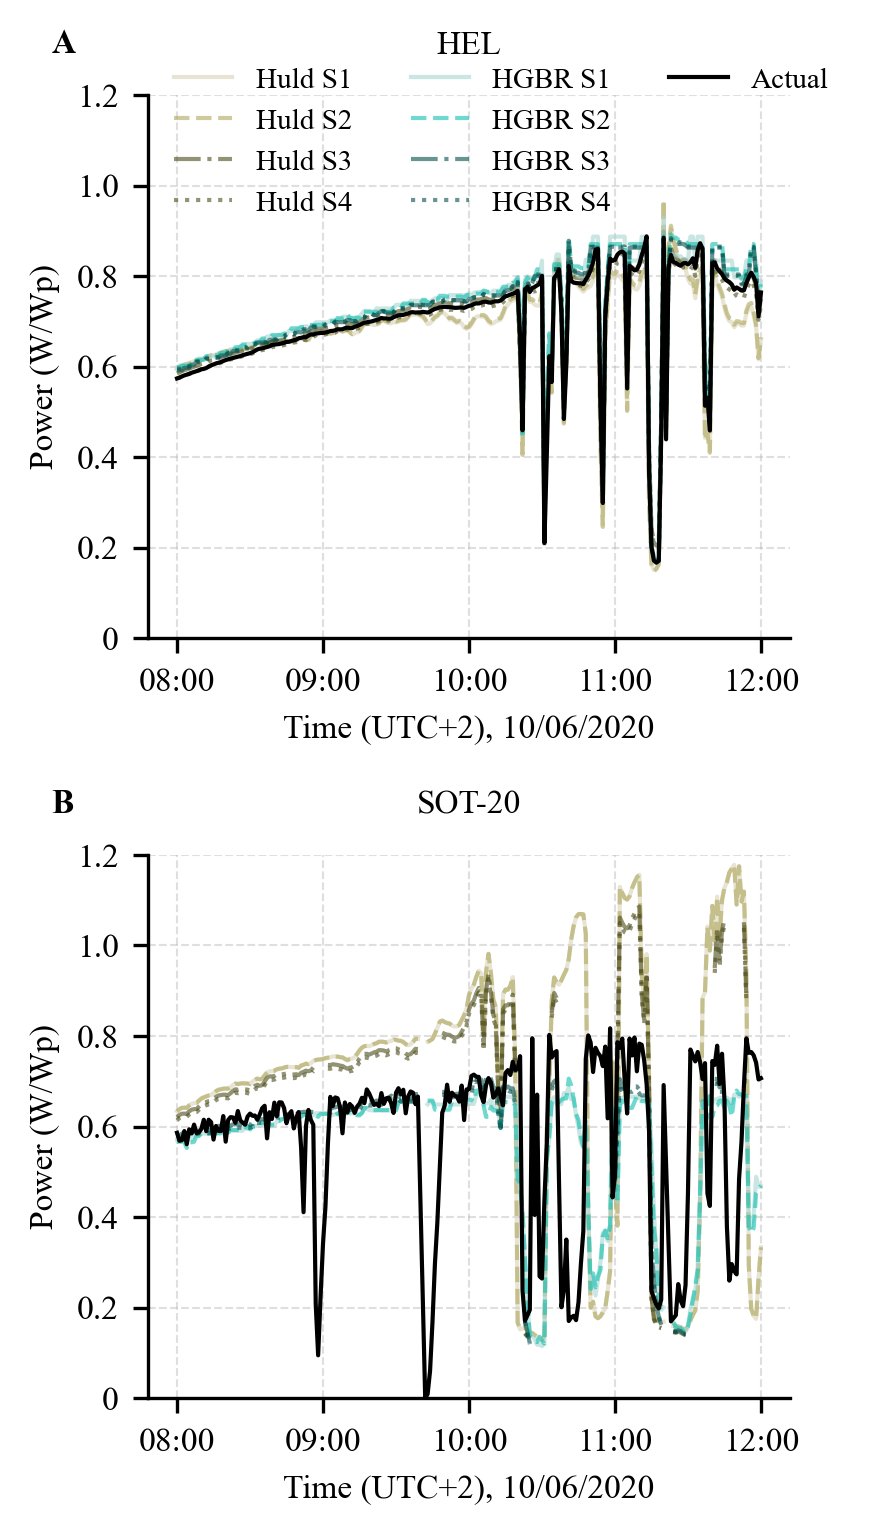

In [ ]:
start_date = "2020-06-10"
day_range = 1

plot_power_profiles(system_scenario_dict=systems_scenarios_df_hel_sot20, 
                    models=model_str_list, 
                    rated_power_list=[SYSTEM_RATED_POWER_DICT["HEL"], SYSTEM_RATED_POWER_DICT["SOT-20"]], 
                    start_date=start_date, 
                    day_range=day_range,
                    starting_utc_time="06:00",
                    ending_utc_time="10:00",
                    show_legend=False,
                    save_figure_path=f"results/HEL-SOT20_profile_{start_date}.jpg"
                    )